Credit Card Fraud Detection using Logistic Regression

Dataset: ULB Machine Learning Group - Credit Card Fraud Detection

Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Objective

The goal of this project is to detect fraudulent credit card transactions using Logistic Regression.

Key Challenges

Highly imbalanced dataset / Need to improve fraud detection (recall) / Avoid overfitting

Approach

Use full dataset (no undersampling) / Apply cost-sensitive learning / Use feature scaling / Evaluate using multiple metrics

In [6]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Model saving
import joblib
import os

Load Dataset

We load the credit card fraud dataset and inspect its structure.

In [9]:
# Load dataset
df = pd.read_csv('creditcard.csv.gz')

print("Dataset Loaded Successfully ✅")

# Display first rows
df.head()

Dataset Loaded Successfully ✅


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Data Exploration

Analyze dataset structure, statistics, and check for missing values.

In [10]:
# Dataset shape
print("Shape:", df.shape)

# Info
df.info()

# Statistical summary
df.describe()

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

Class Distribution

The dataset is highly imbalanced. Most transactions are normal (0), while very few are fraud (1).

Class
0    284315
1       492
Name: count, dtype: int64


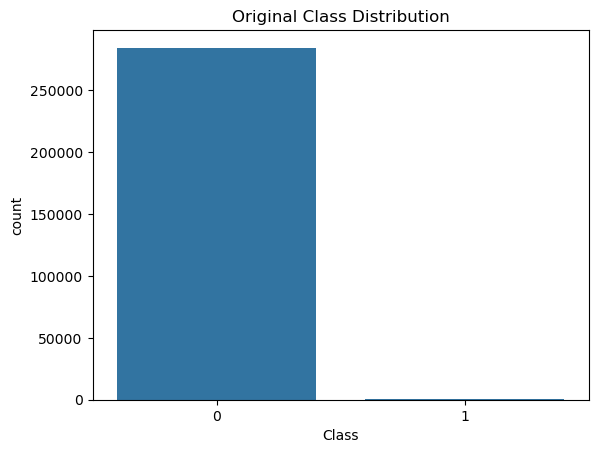

In [11]:
# Count values
print(df['Class'].value_counts())

# Plot distribution
sns.countplot(x='Class', data=df)
plt.title("Original Class Distribution")
plt.show()

Feature Selection

Separate features (X) and target variable (y).

In [12]:
# Separate features and labels
X = df.drop('Class', axis=1)
y = df['Class']